# Chapter 36 — Gage Placement and Structural Testing
### Companion Notebook — Rosette Analysis

*Companion notebook to Chapter 36 — Gage Placement and Structural Testing.*

A single strain gage measures deformation along one direction. At most points on a loaded structure the state of strain is *biaxial* — the principal directions are unknown, and both principal strains are nonzero. To recover the full strain state at a point, at least three independent strain measurements are needed. The **strain rosette** provides them: three gages arranged at known angles to one another, bonded at the same location on the structure.

The **data reduction equations** convert the three gage readings into the complete in-plane strain state: the principal strains ε₁ and ε₂, their orientation θ_p, and the maximum shear strain. From those, the principal stresses follow directly through the plane-stress constitutive relations. This notebook implements the reduction for both the standard **rectangular** (0°–45°–90°) rosette and the **delta** (0°–60°–120°) rosette, and visualizes the result as a stress Mohr's circle.

**This notebook demonstrates:**
1. Full rosette data reduction — three gage readings → principal strains → principal stresses → Mohr's circle (rectangular rosette).
2. The same reduction applied to the delta (0°–60°–120°) rosette for a different strain state.

In [1]:
# !pip install numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# The book includes the figure written to this directory; keep the path and
# filenames exactly as they are so the printed figure stays in sync.
OUT_DIR = Path("../src/media/ch36")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## The reduction, once — then reused

Both rosette types share the same back half of the calculation. Once the three readings are turned into the Cartesian strain components (ε_x, ε_y, γ_xy), the path to the principal strains, their orientation, and the principal stresses is identical. We write that logic once, as four small functions, and call them for each rosette below. Only the *front* step — turning three gage readings into (ε_x, ε_y, γ_xy) — differs between the rectangular and delta geometries.

In [2]:
# Material constants (generic structural steel).
E_STEEL_MPA = 200.0e3   # Young's modulus, MPa
NU_STEEL = 0.30         # Poisson's ratio, dimensionless


def rectangular_rosette(eps_a, eps_b, eps_c):
    """Cartesian in-plane strains from a rectangular (0-45-90 deg) rosette.

    Grid A is at 0 deg, B at 45 deg, C at 90 deg from the reference axis.
    Returns (eps_x, eps_y, gamma_xy) in the same strain units as the inputs.
    """
    eps_x = eps_a
    eps_y = eps_c
    gamma_xy = 2.0 * eps_b - eps_a - eps_c
    return eps_x, eps_y, gamma_xy


def delta_rosette(eps_a, eps_b, eps_c):
    """Cartesian in-plane strains from a delta (0-60-120 deg) rosette.

    Grid A is at 0 deg, B at 60 deg, C at 120 deg from the reference axis.
    Returns (eps_x, eps_y, gamma_xy) in the same strain units as the inputs.
    """
    eps_x = eps_a
    eps_y = (2.0 * (eps_b + eps_c) - eps_a) / 3.0
    gamma_xy = 2.0 * (eps_b - eps_c) / np.sqrt(3.0)
    return eps_x, eps_y, gamma_xy


def principal_strains(eps_x, eps_y, gamma_xy):
    """Principal strains and orientation from Cartesian strain components.

    Returns (eps_1, eps_2, theta_p_deg), with eps_1 >= eps_2 and theta_p_deg
    the angle from the x-axis to the major principal direction, in degrees.
    """
    eps_avg = 0.5 * (eps_x + eps_y)
    radius = np.hypot(0.5 * (eps_x - eps_y), 0.5 * gamma_xy)
    eps_1 = eps_avg + radius
    eps_2 = eps_avg - radius
    theta_p_deg = 0.5 * np.degrees(np.arctan2(gamma_xy, eps_x - eps_y))
    return eps_1, eps_2, theta_p_deg


def principal_stresses(eps_1, eps_2, E, nu):
    """Principal stresses from principal strains via plane-stress Hooke's law.

    E and the returned stresses share units; the strains are dimensionless.
    """
    factor = E / (1.0 - nu ** 2)
    sigma_1 = factor * (eps_1 + nu * eps_2)
    sigma_2 = factor * (eps_2 + nu * eps_1)
    return sigma_1, sigma_2

---
## 1 — Rectangular Rosette (0°–45°–90°) Data Reduction

The **rectangular rosette** is the most common configuration in structural testing. Its three grids sit at 0°, 45°, and 90° from a reference direction. The reduction takes the three readings (ε_A, ε_B, ε_C), forms the average normal strain (ε_A + ε_C)/2 and the in-plane radius — the distance from the center of Mohr's circle to any point on its perimeter — and from those recovers the principal strains and their orientation.

We use the strain state printed in the chapter's figure caption. Once the principal strains are known, plane-stress Hooke's law gives the principal stresses, and we draw the stress Mohr's circle: the principal stresses σ₁ and σ₂ sit where the circle crosses the horizontal axis, and the maximum shear stress τ_max sits at its top and bottom. The circle doubles as a geometric check — if the inputs describe a valid plane-stress state, it closes cleanly.

In [3]:
# Rectangular rosette gage readings (microstrain) — the strain state named in
# the Chapter 36 figure caption.
eps_A_ue, eps_B_ue, eps_C_ue = 450.0, 225.0, -75.0

eps_A, eps_B, eps_C = eps_A_ue * 1e-6, eps_B_ue * 1e-6, eps_C_ue * 1e-6

eps_x, eps_y, gamma_xy = rectangular_rosette(eps_A, eps_B, eps_C)
eps_1, eps_2, theta_p = principal_strains(eps_x, eps_y, gamma_xy)
sigma_1, sigma_2 = principal_stresses(eps_1, eps_2, E_STEEL_MPA, NU_STEEL)
tau_max = 0.5 * (sigma_1 - sigma_2)

print("RECTANGULAR ROSETTE (0-45-90 deg)")
print(f"  ε_A={eps_A_ue:.0f}, ε_B={eps_B_ue:.0f}, ε_C={eps_C_ue:.0f} με")
print(f"  ε₁={eps_1*1e6:.1f}  ε₂={eps_2*1e6:.1f}  γ_xy={gamma_xy*1e6:.1f} με")
print(f"  θ_p={theta_p:.2f}°")
print(f"  σ₁={sigma_1:.1f}  σ₂={sigma_2:.1f} MPa  τ_max={tau_max:.1f} MPa")

RECTANGULAR ROSETTE (0-45-90 deg)
  ε_A=450, ε_B=225, ε_C=-75 με
  ε₁=452.7  ε₂=-77.7  γ_xy=75.0 με
  θ_p=4.07°
  σ₁=94.4  σ₂=12.8 MPa  τ_max=40.8 MPa


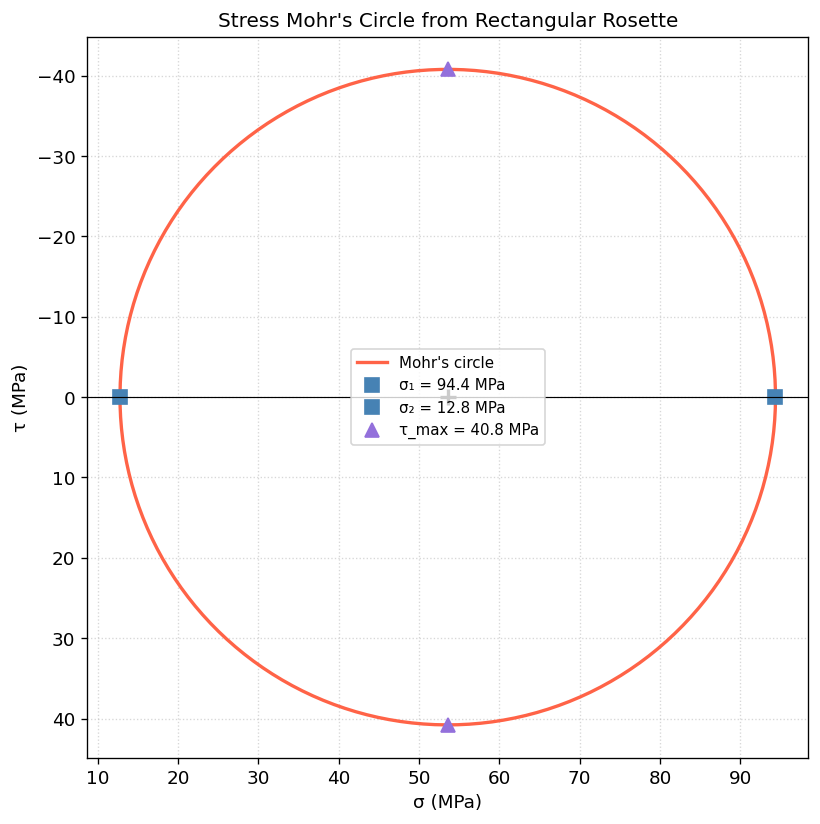

In [4]:
# Stress Mohr's circle for the rectangular-rosette result.
sigma_avg = 0.5 * (sigma_1 + sigma_2)
R_s = 0.5 * (sigma_1 - sigma_2)
circle_angle = np.linspace(0, 2 * np.pi, 360)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(sigma_avg + R_s * np.cos(circle_angle), R_s * np.sin(circle_angle),
        'tomato', lw=2, label="Mohr's circle")
ax.plot(sigma_1, 0, 's', color='steelblue', ms=8, label=f'σ₁ = {sigma_1:.1f} MPa')
ax.plot(sigma_2, 0, 's', color='steelblue', ms=8, label=f'σ₂ = {sigma_2:.1f} MPa')
ax.plot(sigma_avg, R_s, '^', color='mediumpurple', ms=8, label=f'τ_max = {R_s:.1f} MPa')
ax.plot(sigma_avg, -R_s, '^', color='mediumpurple', ms=8)
ax.plot(sigma_avg, 0, '+', color='black', ms=10, markeredgewidth=2)
ax.axhline(0, color='black', lw=0.7)
ax.set_aspect('equal')
ax.set_xlabel('σ (MPa)')
ax.set_ylabel('τ (MPa)')
ax.set_title("Stress Mohr's Circle from Rectangular Rosette")
ax.legend(fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
ax.invert_yaxis()  # plot positive shear downward (common Mohr's-circle convention)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig36_nb1_rosette_mohrs_circle.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 2 — Delta Rosette (0°–60°–120°) Data Reduction

The **delta rosette** spaces its three grids at 60° intervals rather than 45°, over a compact triangular footprint. Because none of its grids lie along the reference axes the way the 0° and 90° grids of a rectangular rosette do, the first step — turning the three readings into (ε_x, ε_y, γ_xy) — uses a different set of transformation equations. Its appeal is *equal sensitivity to strain in all three directions*, which makes it a good choice when the rosette's orientation relative to the load is unknown. (The rectangular rosette remains more common precisely because its reduction equations are simpler.)

The code below applies `delta_rosette` to get the Cartesian strain components, then reuses the very same `principal_strains` and `principal_stresses` helpers as the rectangular case. A different strain state is used here so the two reductions can be compared side by side.

In [5]:
# Delta rosette gage readings (microstrain) for a different strain state.
eps_A2_ue, eps_B2_ue, eps_C2_ue = 800.0, 200.0, -100.0
eps_A2, eps_B2, eps_C2 = eps_A2_ue * 1e-6, eps_B2_ue * 1e-6, eps_C2_ue * 1e-6

eps_x2, eps_y2, gamma_xy2 = delta_rosette(eps_A2, eps_B2, eps_C2)
eps_1d, eps_2d, theta_pd = principal_strains(eps_x2, eps_y2, gamma_xy2)
sigma_1d, sigma_2d = principal_stresses(eps_1d, eps_2d, E_STEEL_MPA, NU_STEEL)

print("DELTA ROSETTE (0-60-120 deg)")
print(f"  ε_A={eps_A2_ue:.0f}, ε_B={eps_B2_ue:.0f}, ε_C={eps_C2_ue:.0f} με")
print(f"  ε₁={eps_1d*1e6:.1f}  ε₂={eps_2d*1e6:.1f}  θ_p={theta_pd:.2f}°")
print(f"  σ₁={sigma_1d:.1f}  σ₂={sigma_2d:.1f} MPa")

DELTA ROSETTE (0-60-120 deg)
  ε_A=800, ε_B=200, ε_C=-100 με
  ε₁=829.2  ε₂=-229.2  θ_p=9.55°
  σ₁=167.1  σ₂=4.3 MPa


---
## 3 — Gage Length on Woven Composites: How Much Averaging Is Enough?

A gage on a woven laminate sits on a surface whose stiffness is *periodic*. Under a
uniform far-field load the local surface strain is low over a tow running along the load
and high over the transverse tow and the resin pocket between them. The gage reads the
mean of that field over its active length, which makes it a **boxcar (moving-average)
filter** applied to a periodic signal — and that is a problem with a closed-form answer.

For a field $\varepsilon(x) = \bar\varepsilon + A\sin(2\pi x/p + \phi)$ of period $p$, a gage
of active length $L$ returns

$$\varepsilon_{\text{gage}} = \bar\varepsilon + A\,\operatorname{sinc}(L/p)\times(\text{phase}),
\qquad \operatorname{sinc}(n)=\frac{\sin \pi n}{\pi n}.$$

Where the grid lands sets only the phase, so for a given $n = L/p$ the **worst case over
placement** is $A\,|\operatorname{sinc}(n)|$. Its zeros at integer $n$ are not usable: the active
length carries a tolerance and a real fabric's pitch wanders by a few percent, so $n$ is never
known well enough to sit on a zero. What governs the design is the envelope over fractional $n$,
$A/(\pi n)$, the **worst case over gage-length tolerance and pitch variation**. The middle panel
shows the realized error for one modeled fabric (pitch wander $\pm6\%$); it falls under the bound.

**The subtlety that decides the rule** is what $p$ actually is. In a plain weave the
over-under interlacing repeats only after *two* tows in each direction, so the period of
the strain field is **twice the tow pitch** — and for a satin it is much longer still.
A rule expressed in tows is therefore only safe for one architecture.

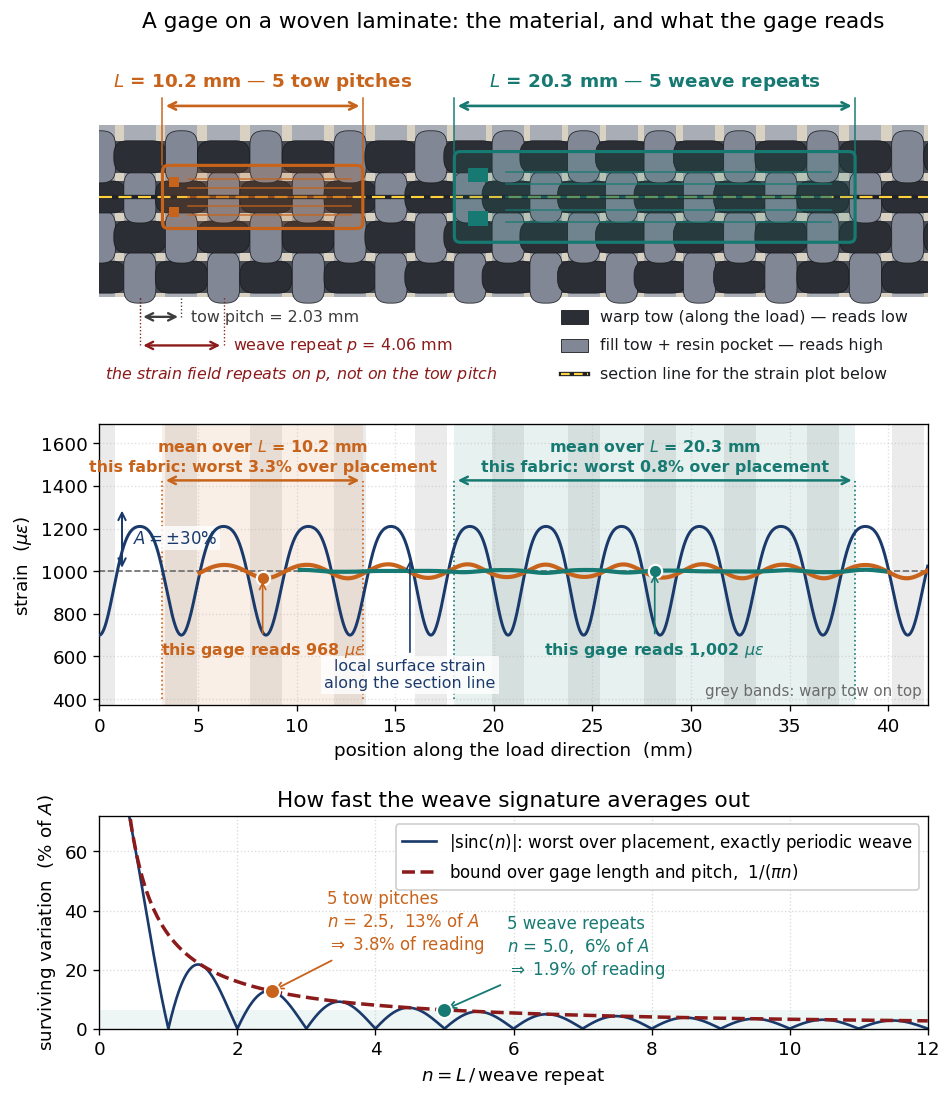

panel A drawn 1:1 — 42 mm wide x 16.5 mm tall, fabric 8.7 mm (4 warp tows)
tow pitch 2.03 mm | plain-weave repeat 4.06 mm
pitch wander used in the model: +/-6%

architecture           tows/rep  repeat mm   L for 5 repeats
Plain weave (1/1)             2       4.06           20.3 mm
Twill 2/2                     4       8.13           40.6 mm
5-harness satin               5      10.16           50.8 mm
8-harness satin               8      16.26           81.3 mm



5 tow pitches      L =  10.2 mm  n = 2.50  envelope  12.7% of A -> 3.8% of reading | modelled residual 3.3%


5 weave repeats    L =  20.3 mm  n = 5.00  envelope   6.4% of A -> 1.9% of reading | modelled residual 0.8%

n required for a 2% reading error at A = 30%: 4.77 repeats


In [6]:
# --- Figure 36.5: how a gage averages the periodic strain field of a woven laminate ---
from matplotlib.patches import Rectangle, FancyBboxPatch

# The book prints this at up to 5.9 in wide, height-capped at 0.68\textheight, in a
# 6.25 in text block; the source is 7.8 in wide, so labels are sized for roughly a 0.7x
# reduction.

# ---- fabric: representative 3K plain-weave carbon, 12.5 tows/inch ------------------
TOWS_PER_INCH = 12.5
PITCH  = 25.4 / TOWS_PER_INCH        # tow centre-to-centre spacing, mm
PERIOD = 2.0 * PITCH                 # plain weave: interlacing repeats every 2 tows
TOW_W  = 0.80 * PITCH                # tow width; the balance is the resin pocket

EPS_BAR = 1000.0                     # far-field mean strain, ue
A_FRAC  = 0.30                       # local variation, +/- fraction of the mean
A_UE    = A_FRAC * EPS_BAR

XMAX = 42.0                          # shared x-axis span of panels A and B, mm
x  = np.linspace(0, 50.0, 50001)
dx = x[1] - x[0]

# A real fabric is not a perfect grating: pitch wanders by a few percent across a panel.
# That matters, because an exactly periodic field averaged over an exactly integer
# number of repeats cancels to zero -- a degenerate case no installation can rely on.
PITCH_WANDER = 0.06
p_local = PERIOD*(1 + PITCH_WANDER*np.sin(2*np.pi*x/31.0))
phase   = 2*np.pi*np.cumsum(dx/p_local)      # 2*pi per weave repeat

# Slightly peaked: the resin pocket concentrates strain more sharply than the stiff
# load-direction tow relieves it. Phase 0 (mod 2pi) is a warp-on-top crossing.
raw = -(0.85*np.cos(phase) + 0.15*np.cos(2*phase))
eps = EPS_BAR + A_UE*raw/np.max(np.abs(raw))

# Transverse-tow centres sit every half repeat -- i.e. every pi of phase.
k_tow = np.arange(0, int(phase[-1]/np.pi) + 1)
tow_x = np.interp(k_tow*np.pi, phase, x)     # k even: warp on top (strain minimum)

def running_mean(sig, L):
    """Mean over a window of length L mm, returned at the window centre."""
    w = max(int(round(L/dx)), 1)
    return np.convolve(sig, np.ones(w)/w, mode='valid'), w

L_TOW = 5*PITCH       # "5 x warp/fill" read as 5 tow pitches
L_REP = 5*PERIOD      # "5 x warp/fill" read as 5 weave repeats
X0_TOW, X0_REP = 3.2, 18.0                   # where each gage is drawn on the fabric
GW_TOW, GW_REP = 3.2, 4.6                    # grid widths, from the gage catalog, mm

RESIN   = '#d9d2c2'
WARP_T, WARP_U = '#2b2e34', '#474b53'        # load-direction tow: on top / passing under
FILL_T, FILL_U = '#818794', '#a8adb6'        # transverse tow: on top / passing under
SECT    = '#ffd23d'                          # the section line the strain is taken along
NAVY, COPPER, TEAL, GREY = '#1a3a6b', '#c8631b', '#177a72', '#6b6b6b'

fig  = plt.figure(figsize=(7.8, 8.9))
outer = fig.add_gridspec(2, 1, height_ratios=[2.55, 0.85], hspace=0.26)
inner = outer[0].subgridspec(2, 1, height_ratios=[1.45, 1.25], hspace=0.10)
axA = fig.add_subplot(inner[0])
axB = fig.add_subplot(inner[1])
axC = fig.add_subplot(outer[1])
fig.subplots_adjust(left=0.100, right=0.985, top=0.960, bottom=0.060)

# ===================== panel A: the material, drawn to scale ========================
DIM_B, DIM_T = 4.9, 2.9          # dimension strips below and above the fabric
axA.set_xlim(0, XMAX)
fig.canvas.draw()                                    # fix the axes box, then...
_pos   = axA.get_position()
_w_in  = _pos.width  * fig.get_figwidth()
_h_in  = _pos.height * fig.get_figheight()
SPAN_Y = XMAX * _h_in / _w_in                        # ...1:1 scale, so tows are square
H_FAB  = SPAN_Y - DIM_B - DIM_T
axA.set_ylim(-DIM_B, H_FAB + DIM_T)

warp_y = np.arange(0.5*PITCH, H_FAB, PITCH)          # warp tows run along the load

def capsule(ax, xc, yc, length, width, horiz, fc, z):
    """One visible tow segment, rounded where it dives under its neighbour."""
    w, h = (length, width) if horiz else (width, length)
    ax.add_patch(FancyBboxPatch((xc - w/2, yc - h/2), w, h,
                                boxstyle=f'round,pad=0,rounding_size={0.42*width}',
                                fc=fc, ec='#1a1c20', lw=0.45, zorder=z))

axA.add_patch(Rectangle((0, 0), XMAX, H_FAB, fc=RESIN, ec='none', zorder=0))
# tows passing underneath: continuous, but recessed (lighter, drawn first)
for xc in tow_x:
    axA.add_patch(Rectangle((xc - TOW_W/2, 0), TOW_W, H_FAB,
                            fc=FILL_U, ec='none', zorder=1))
for yc in warp_y:
    axA.add_patch(Rectangle((0, yc - TOW_W/2), XMAX, TOW_W,
                            fc=WARP_U, ec='none', zorder=2))
# tows crossing over: one rounded segment per crossing, which is what reads as weave
SEG = 1.30*PITCH
for j, yc in enumerate(warp_y):
    for k, xc in zip(k_tow, tow_x):
        if (j + k) % 2 == 0:
            capsule(axA, xc, yc, SEG, TOW_W, True,  WARP_T, 4)
        else:
            capsule(axA, xc, yc, SEG, TOW_W, False, FILL_T, 4)

# The strain trace below is taken along one warp tow -- say which.
j_sec = 2*max(int(len(warp_y)//4), 1)                # an even row: warp on top at k even
y_sec = warp_y[j_sec]
axA.plot([0, XMAX], [y_sec, y_sec], color='#20232a', lw=2.6, zorder=5)
axA.plot([0, XMAX], [y_sec, y_sec], color=SECT, lw=1.3, ls=(0, (6, 3)), zorder=6)

def draw_gage(ax, x0, L, yc, gw, col, tag):
    """A foil gage footprint: carrier, grid, tabs -- and its L dimension."""
    ax.add_patch(FancyBboxPatch((x0, yc - gw/2), L, gw,
                                boxstyle='round,pad=0,rounding_size=0.30',
                                fc=col, ec='none', alpha=0.16, zorder=7))
    ax.add_patch(FancyBboxPatch((x0, yc - gw/2), L, gw,
                                boxstyle='round,pad=0,rounding_size=0.30',
                                fc='none', ec=col, lw=1.9, zorder=9))
    for yy in np.linspace(yc - 0.28*gw, yc + 0.28*gw, 5):        # the grid
        ax.plot([x0 + 0.13*L, x0 + 0.94*L], [yy, yy], color=col, lw=0.9,
                alpha=0.85, zorder=8)
    for dy in (-0.24, 0.24):                                     # solder tabs
        ax.add_patch(Rectangle((x0 + 0.035*L, yc + dy*gw - 0.08*gw),
                               0.05*L, 0.16*gw, fc=col, ec='none', zorder=8))
    ytop = H_FAB + 0.95                                          # dimension, above
    for xe in (x0, x0 + L):
        ax.plot([xe, xe], [yc + gw/2, ytop + 0.40], color=col, lw=0.9, zorder=6)
    ax.annotate('', xy=(x0, ytop), xytext=(x0 + L, ytop),
                arrowprops=dict(arrowstyle='<->', color=col, lw=1.6), zorder=10)
    ax.text(x0 + L/2, ytop + 0.70, tag, ha='center', va='bottom',
            fontsize=11, color=col, weight='bold', zorder=10)

draw_gage(axA, X0_TOW, L_TOW, y_sec, GW_TOW, COPPER,
          f'$L$ = {L_TOW:.1f} mm — 5 tow pitches')
draw_gage(axA, X0_REP, L_REP, y_sec, GW_REP, TEAL,
          f'$L$ = {L_REP:.1f} mm — 5 weave repeats')

# ---- strip below the fabric: dimensions on the left, key on the right --------------
def dim(ax, xa, xb, y, col, label):
    ax.annotate('', xy=(xa, y), xytext=(xb, y),
                arrowprops=dict(arrowstyle='<->', color=col, lw=1.4))
    for xe in (xa, xb):
        ax.plot([xe, xe], [y, 0], color=col, lw=0.8, ls=':', zorder=5)
    ax.text(xb + 0.5, y, label, ha='left', va='center', fontsize=9.5, color=col)

KEY_X, KEY_T, ROWS = 23.4, 25.4, (-1.00, -2.45, -3.90)
dim(axA, tow_x[1], tow_x[2], ROWS[0], '#3d3d3d', f'tow pitch = {PITCH:.2f} mm')
dim(axA, tow_x[1], tow_x[3], ROWS[1], '#8b1a1a', f'weave repeat $p$ = {PERIOD:.2f} mm')
axA.text(0.3, ROWS[2], 'the strain field repeats on $p$, not on the tow pitch',
         ha='left', va='center', fontsize=9.5, color='#8b1a1a', style='italic')

for c, lab, yk in ((WARP_T, 'warp tow (along the load) — reads low',  ROWS[0]),
                   (FILL_T, 'fill tow + resin pocket — reads high',   ROWS[1])):
    axA.add_patch(Rectangle((KEY_X, yk - 0.34), 1.4, 0.68, fc=c, ec='#1a1c20', lw=0.5))
    axA.text(KEY_T, yk, lab, va='center', fontsize=9.5, color='#1a1c20')
axA.plot([KEY_X, KEY_X + 1.4], [ROWS[2]]*2, color='#20232a', lw=2.6)
axA.plot([KEY_X, KEY_X + 1.4], [ROWS[2]]*2, color=SECT, lw=1.3, ls=(0, (4, 2)))
axA.text(KEY_T, ROWS[2], 'section line for the strain plot below',
         va='center', fontsize=9.5, color='#1a1c20')

axA.set_title('A gage on a woven laminate: the material, and what the gage reads',
              fontsize=13, pad=24)
axA.set_yticks([]); axA.set_xticks(np.arange(0, XMAX + 1, 5))
axA.tick_params(labelbottom=False, length=0)
for s in axA.spines.values():
    s.set_visible(False)

# ===================== panel B: the strain along that section line ==================
for k, xc in zip(k_tow, tow_x):                   # same bands, phase-locked to panel A
    if k % 2 == 0:
        axB.axvspan(xc - TOW_W/2, xc + TOW_W/2, color='0.92', lw=0, zorder=0)

axB.axhline(EPS_BAR, color=GREY, lw=1.0, ls='--', zorder=2)
axB.plot(x, eps, color=NAVY, lw=1.8, zorder=4)
axB.annotate('local surface strain\nalong the section line',
             xy=(15.75, np.interp(15.75, x, eps)), xytext=(15.75, EPS_BAR - 1.62*A_UE),
             ha='center', va='center', fontsize=9.5, color=NAVY, zorder=9,
             arrowprops=dict(arrowstyle='->', color=NAVY, lw=1.0),
             bbox=dict(fc='white', ec='none', alpha=0.82, pad=1.8))

for L, x0, col, tag in ((L_TOW, X0_TOW, COPPER, '5 tow pitches'),
                        (L_REP, X0_REP, TEAL,   '5 weave repeats')):
    avg, w = running_mean(eps, L)
    xc_all = x[w//2: w//2 + len(avg)]
    res = np.max(np.abs(avg - EPS_BAR))/EPS_BAR*100
    axB.plot(xc_all, avg, color=col, lw=2.5, zorder=6)
    # the one window drawn on the fabric above: shade it, mark what it averages to
    axB.axvspan(x0, x0 + L, color=col, alpha=0.10, lw=0, zorder=1)
    for xe in (x0, x0 + L):
        axB.plot([xe, xe], [EPS_BAR - 2.00*A_UE, EPS_BAR + 1.42*A_UE],
                 color=col, lw=1.0, ls=':', zorder=3)
    xm = x0 + L/2
    ym = float(np.interp(xm, xc_all, avg))
    axB.plot([xm], [ym], 'o', color=col, ms=8, mec='white', mew=1.3, zorder=8)
    axB.annotate(f'this gage reads {ym:,.0f} $\\mu\\varepsilon$',
                 xy=(xm, ym), xytext=(xm, EPS_BAR - 1.30*A_UE),
                 ha='center', fontsize=9.5, color=col, weight='bold',
                 arrowprops=dict(arrowstyle='->', color=col, lw=1.0), zorder=9)
    axB.annotate('', xy=(x0, EPS_BAR + 1.42*A_UE), xytext=(x0 + L, EPS_BAR + 1.42*A_UE),
                 arrowprops=dict(arrowstyle='<->', color=col, lw=1.5))
    axB.text(xm, EPS_BAR + 1.52*A_UE,
             f'mean over $L$ = {L:.1f} mm\nthis fabric: worst {res:.1f}% over placement',
             ha='center', va='bottom', fontsize=9.5, color=col, weight='bold',
             linespacing=1.35)

axB.set_xlim(0, XMAX); axB.set_ylim(EPS_BAR - 2.10*A_UE, EPS_BAR + 2.30*A_UE)
axB.set_xticks(np.arange(0, XMAX + 1, 5))
axB.set_xlabel('position along the load direction  (mm)')
axB.set_ylabel(r'strain  ($\mu\varepsilon$)')
axB.grid(True, ls=':', alpha=0.40)
axB.annotate('', xy=(1.15, EPS_BAR), xytext=(1.15, EPS_BAR + A_UE),
             arrowprops=dict(arrowstyle='<->', color=NAVY, lw=1.2))
axB.text(1.7, EPS_BAR + 0.44*A_UE, r'$A=\pm%d\%%$' % (A_FRAC*100),
         fontsize=10, color=NAVY, ha='left',
         bbox=dict(fc='white', ec='none', alpha=0.82, pad=1.6))
axB.text(0.993, 0.035, 'grey bands: warp tow on top', transform=axB.transAxes,
         ha='right', fontsize=9, color='0.42')

# ===================== panel C: attenuation vs number of repeats ====================
n = np.linspace(0.25, 12, 4000)
axC.plot(n, np.abs(np.sin(np.pi*n)/(np.pi*n))*100, color=NAVY, lw=1.6,
         label=r'$|\mathrm{sinc}(n)|$: worst over placement, exactly periodic weave')
axC.plot(n, 100/(np.pi*n), color='#8b1a1a', lw=2.1, ls='--',
         label=r'bound over gage length and pitch,  $1/(\pi n)$')

for nv, col, lab, dxy in ((L_TOW/PERIOD, COPPER, '5 tow pitches', (0.80, 14)),
                          (L_REP/PERIOD, TEAL,   '5 weave repeats', (0.90, 12))):
    env = 100/(np.pi*nv)
    axC.plot([nv], [env], 'o', color=col, ms=9, mec='white', mew=1.2, zorder=5)
    axC.annotate(f'{lab}\n$n$ = {nv:.1f},  {env:.0f}% of $A$\n'
                 fr'$\Rightarrow$ {env*A_FRAC:.1f}% of reading',
                 xy=(nv, env), xytext=(nv + dxy[0], env + dxy[1]),
                 fontsize=10, color=col,
                 arrowprops=dict(arrowstyle='->', color=col, lw=1.1))

axC.axhspan(0, 100/(np.pi*5), color=TEAL, alpha=0.07, lw=0)
axC.set_xlim(0, 12); axC.set_ylim(0, 72)
axC.set_xlabel(r'$n = L\,/\,$weave repeat')
axC.set_ylabel('surviving variation  (% of $A$)')
axC.set_title('How fast the weave signature averages out', fontsize=13)
axC.legend(fontsize=10, loc='upper right', framealpha=0.93)
axC.grid(True, ls=':', alpha=0.45)

fig.savefig(OUT_DIR / 'fig36_nb2_weave_averaging.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

# ---------------- the numbers quoted in the chapter --------------------------------
print(f'panel A drawn 1:1 — {XMAX:.0f} mm wide x {SPAN_Y:.1f} mm tall, '
      f'fabric {H_FAB:.1f} mm ({len(warp_y)} warp tows)')
print(f'tow pitch {PITCH:.2f} mm | plain-weave repeat {PERIOD:.2f} mm')
print(f'pitch wander used in the model: +/-{PITCH_WANDER*100:.0f}%\n')
print(f'{"architecture":<22}{"tows/rep":>9}{"repeat mm":>11}{"L for 5 repeats":>18}')
for name, tpr in (('Plain weave (1/1)', 2), ('Twill 2/2', 4),
                  ('5-harness satin', 5), ('8-harness satin', 8)):
    print(f'{name:<22}{tpr:>9}{tpr*PITCH:>11.2f}{5*tpr*PITCH:>15.1f} mm')
print()
for L, lab in ((L_TOW, '5 tow pitches'), (L_REP, '5 weave repeats')):
    nv  = L/PERIOD
    avg, _ = running_mean(eps, L)
    print(f'{lab:<18} L = {L:5.1f} mm  n = {nv:.2f}  '
          f'envelope {100/(np.pi*nv):5.1f}% of A -> {A_FRAC*100/(np.pi*nv):.1f}% of reading '
          f'| modelled residual {np.max(np.abs(avg-EPS_BAR))/EPS_BAR*100:.1f}%')
print(f'\nn required for a 2% reading error at A = {A_FRAC*100:.0f}%: '
      f'{A_FRAC/(np.pi*0.02):.2f} repeats')


---
## Where to take this next

- **Correct for transverse sensitivity.** A real grid responds slightly to strain perpendicular to it. Fold the manufacturer's transverse-sensitivity coefficient K_t into `rectangular_rosette` and `delta_rosette`, then compare the corrected principal strains against the raw reduction — the shift is often a percent or two, which is the difference between an acceptable and an unacceptable result in precision work.
- **Propagate measurement uncertainty.** Wrap the reduction in a Monte Carlo loop: perturb each gage reading by its uncertainty (say ±5 με) using a seeded `rng = np.random.default_rng(0)`, run a few thousand trials, and report the spread in θ_p, σ₁, and σ₂. You will find the principal *angle* is far more sensitive than the principal *stresses* when the circle is small — a practical warning about rosettes on lightly loaded structures.
- **Draw the gage frame onto the circle.** Add the (σ_x, τ_xy) point for the gage coordinate frame to the Mohr's circle and connect it through the center to its conjugate face. The 2θ_p rotation between that chord and the σ-axis becomes visible, tying this reduction back to the Mohr's-circle construction of Chapter 17.